In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Fetch peer-reviewed diagnostic tumor dataset instantly
print("Loading Breast Cancer Diagnostic dataset...")
raw_data = load_breast_cancer()
X_df = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
y_df = pd.Series(raw_data.target, name='tumor_class')

# Merge into one clean working dataframe
df = pd.concat([X_df, y_df], axis=1)
print(f"Dataset Loaded Successfully! Shape: {df.shape}")
print("Classes mapped as -> 0: Malignant, 1: Benign")

Loading Breast Cancer Diagnostic dataset...
Dataset Loaded Successfully! Shape: (569, 31)
Classes mapped as -> 0: Malignant, 1: Benign


--- Dataset Structural Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64

/tmp/ipykernel_1088/3377921788.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='tumor_class', data=df, palette='Set1')
/tmp/ipykernel_1088/3377921788.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tumor_class', y='mean radius', data=df, palette='Set2')


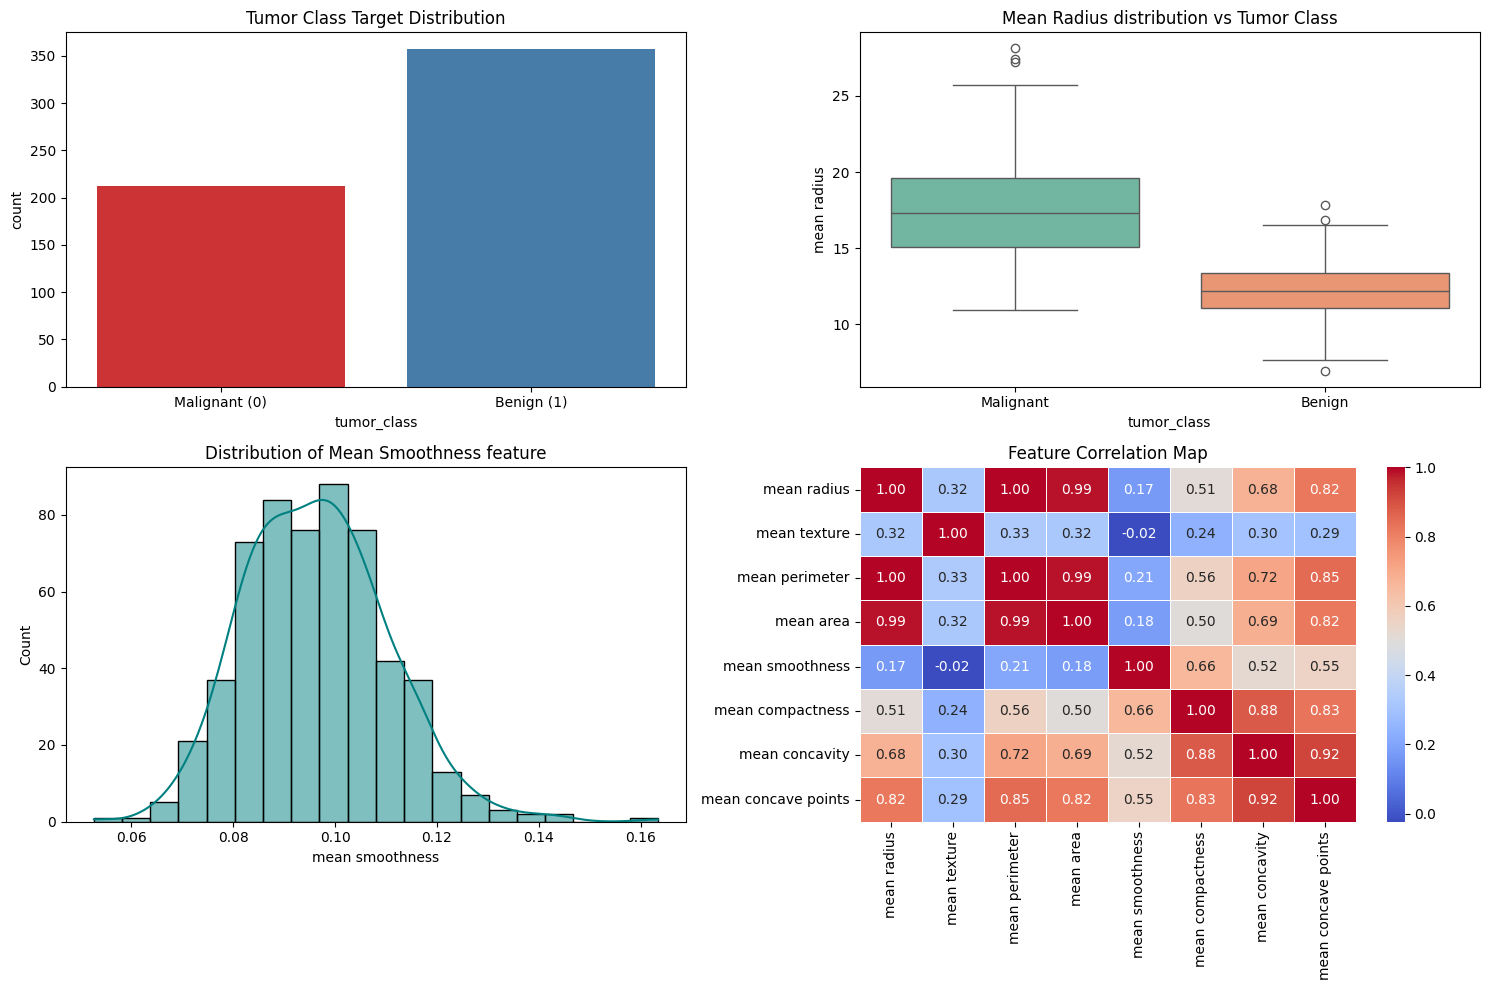

In [2]:
# --- 1. Dataset Inspection & Integrity Checks ---
print("--- Dataset Structural Info ---")
print(df.info())

print("\n--- Checking for Missing Values ---")
print(df.isnull().sum().sum())  # Sum of all missing spaces

print("\n--- Checking for Duplicate Records ---")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

print("\n--- Descriptive Statistics for Tumor Features ---")
print(df.describe().T.head(10)) # Showing a snippet of key metric limits

# --- 2. Required Statistical Visualizations ---
plt.figure(figsize=(15, 10))

# Target Variable Distribution (Class Imbalance Tracking)
plt.subplot(2, 2, 1)
sns.countplot(x='tumor_class', data=df, palette='Set1')
plt.xticks(ticks=[0, 1], labels=['Malignant (0)', 'Benign (1)'])
plt.title('Tumor Class Target Distribution')

# Boxplot of Mean Radius across both tumor labels
plt.subplot(2, 2, 2)
sns.boxplot(x='tumor_class', y='mean radius', data=df, palette='Set2')
plt.xticks(ticks=[0, 1], labels=['Malignant', 'Benign'])
plt.title('Mean Radius distribution vs Tumor Class')

# Mean Smoothness Histogram
plt.subplot(2, 2, 3)
sns.histplot(df['mean smoothness'], kde=True, color='teal', bins=20)
plt.title('Distribution of Mean Smoothness feature')

# Core Correlation Matrix Heatmap
plt.subplot(2, 2, 4)
core_features = df.columns[:8] # subsetting first 8 structural features for visualization clarity
sns.heatmap(df[core_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Map')

plt.tight_layout()
plt.show()

In [3]:
# Separate features and target
X = df.drop('tumor_class', axis=1)
y = df['tumor_class']

# Standard 80-20 Train-Test split stratified evenly by tumor classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Feature Scaling (Standardization is critical for tabular performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data Preprocessing Finished Successfully.")
print(f"Training set dimension: {X_train_scaled.shape} | Testing set dimension: {X_test_scaled.shape}")

Data Preprocessing Finished Successfully.
Training set dimension: (455, 30) | Testing set dimension: (114, 30)


In [4]:
# Initialize Ensemble Models as requested by requirements document
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, eval_metric='logloss', random_state=42)
}

results = {}

# Fit and run evaluations
for name, model in models.items():
    print(f"Training & Cross-Validating {name}...")

    # 5-Fold Cross Validation check to trace structural overfitting
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    # Fit model over full training matrix
    model.fit(X_train_scaled, y_train)

    # Run test predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Save standard classification report statistics
    results[name] = {
        "CV Accuracy Mean": np.mean(cv_scores),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Y_Prob": y_prob
    }
print("\nAll ensemble configurations evaluated successfully!")

Training & Cross-Validating Random Forest...
Training & Cross-Validating AdaBoost...
Training & Cross-Validating XGBoost...

All ensemble configurations evaluated successfully!



--- FINAL ENSEMBLE COMPARISON REPORT TABLE ---
              CV Accuracy Mean Test Accuracy Precision    Recall  F1 Score  \
Random Forest         0.949451       0.95614  0.958904  0.972222  0.965517   
AdaBoost              0.962637       0.95614  0.946667  0.986111  0.965986   
XGBoost               0.967033      0.947368  0.945946  0.972222  0.958904   

                ROC-AUC  
Random Forest  0.993386  
AdaBoost       0.989418  
XGBoost        0.994378  


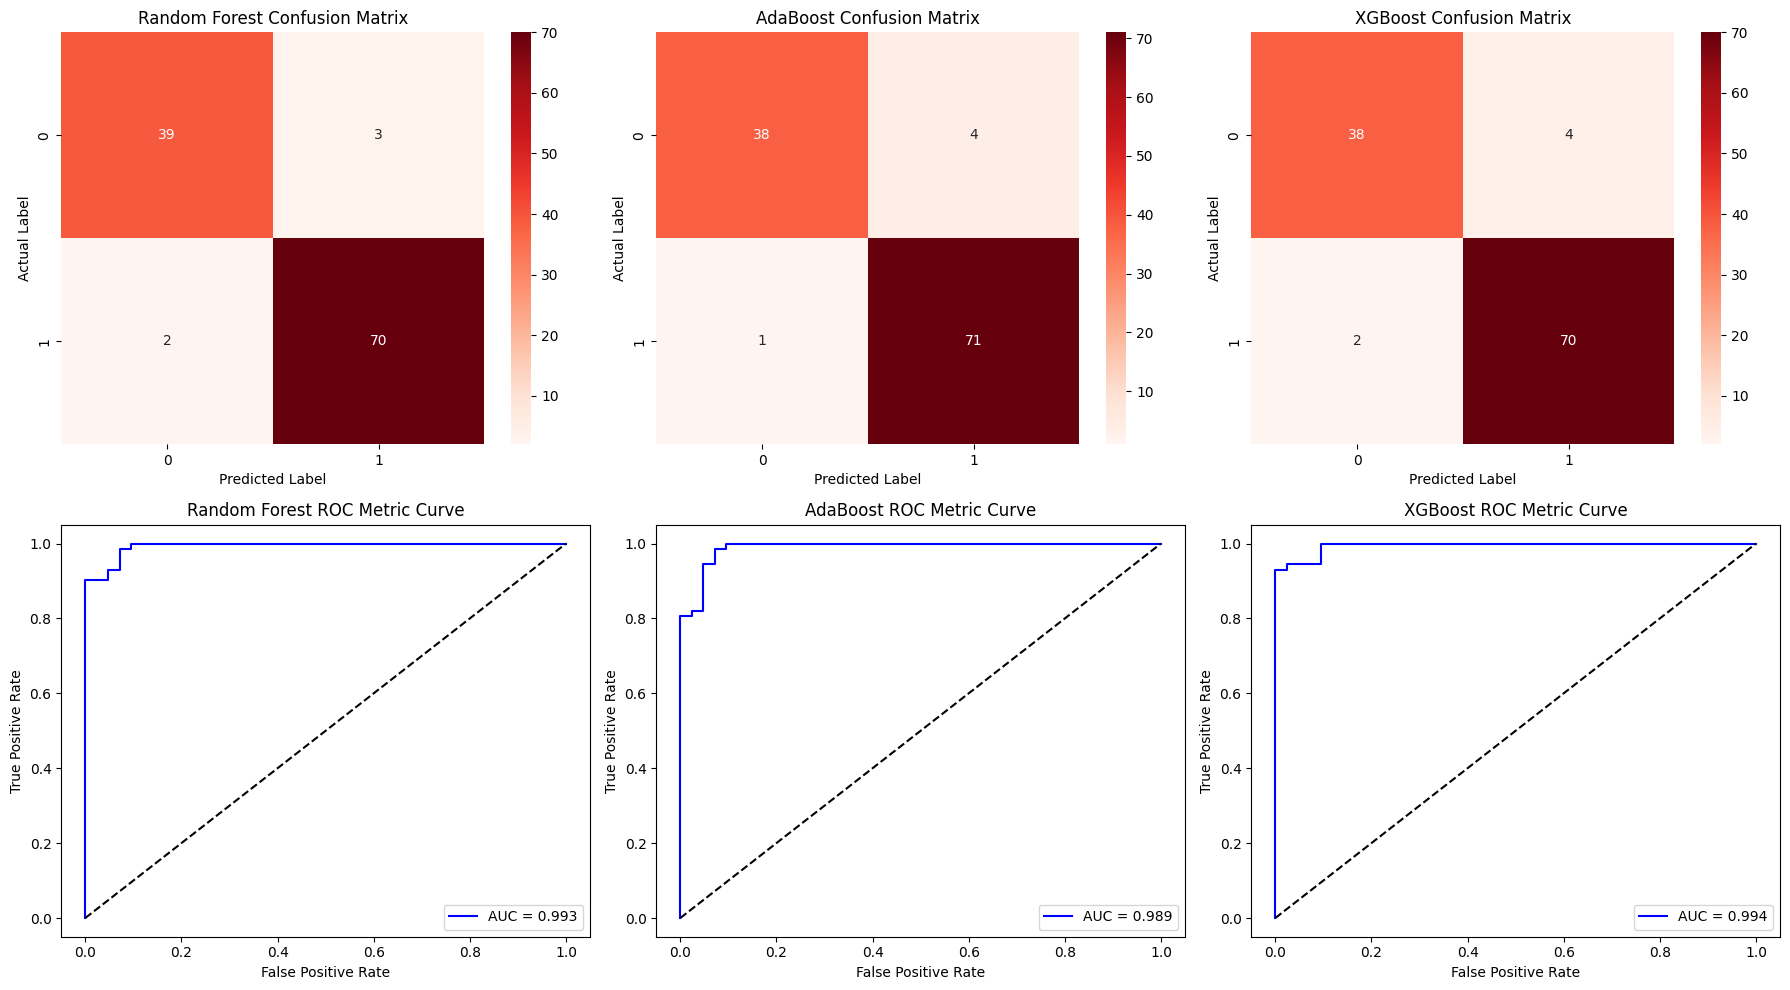

In [5]:
# Convert tracking metrics dict to tabular comparison dataframe
df_metrics = pd.DataFrame(results).T.iloc[:, :6]
print("\n--- FINAL ENSEMBLE COMPARISON REPORT TABLE ---")
print(df_metrics)

# Draw performance graphs
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, metrics) in enumerate(results.items()):
    # Subplot row 1: Heatmap Confusion Matrices
    sns.heatmap(metrics["Confusion Matrix"], annot=True, fmt='d', cmap='Reds', ax=axes[0, idx])
    axes[0, idx].set_title(f'{name} Confusion Matrix')
    axes[0, idx].set_xlabel('Predicted Label')
    axes[0, idx].set_ylabel('Actual Label')

    # Subplot row 2: ROC Curves
    fpr, tpr, _ = roc_curve(y_test, metrics["Y_Prob"])
    axes[1, idx].plot(fpr, tpr, label=f'AUC = {metrics["ROC-AUC"]:.3f}', color='blue')
    axes[1, idx].plot([0, 1], [0, 1], 'k--')
    axes[1, idx].set_title(f'{name} ROC Metric Curve')
    axes[1, idx].set_xlabel('False Positive Rate')
    axes[1, idx].set_ylabel('True Positive Rate')
    axes[1, idx].legend(loc='lower right')

plt.tight_layout()
plt.show()